### **데이터 탐색**

In [69]:
# 라이브러리 호출
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

---
#### **같은 티어별, 게임 아이디별 유저 수**
- 한 게임당 8명이 배정되어야 게임이 시작됨

In [70]:
df_Platinum_Match = pd.read_csv('./tft_game_dataset/TFT_Platinum_MatchData.csv')
df_Diamond_Match = pd.read_csv('./tft_game_dataset/TFT_Diamond_MatchData.csv')
df_Master_Match = pd.read_csv('./tft_game_dataset/TFT_Master_MatchData.csv')
df_GrandMaster_Match = pd.read_csv('./tft_game_dataset/TFT_GrandMaster_MatchData.csv')
df_Challenger_Match = pd.read_csv('./tft_game_dataset/TFT_Challenger_MatchData.csv')

In [71]:
df_Challenger_Match.info()

<class 'pandas.DataFrame'>
RangeIndex: 79999 entries, 0 to 79998
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gameId          79999 non-null  str    
 1   gameDuration    79999 non-null  float64
 2   level           79999 non-null  int64  
 3   lastRound       79999 non-null  int64  
 4   Ranked          79999 non-null  int64  
 5   ingameDuration  79999 non-null  float64
 6   combination     79999 non-null  str    
 7   champion        79999 non-null  str    
dtypes: float64(2), int64(3), str(3)
memory usage: 4.9 MB


In [72]:
df_Challenger_Match.head()

,gameId,gameDuration,level,lastRound,Ranked,ingameDuration,combination,champion
0,KR_4247538593,2142.470703,8,35,1,2134.272217,"{'DarkStar': 2, 'Protector': 4, 'Rebel': 1, 'S...","{'JarvanIV': {'items': [27], 'star': 3}, 'Sona..."
1,KR_4247538593,2142.470703,9,35,2,2134.272217,"{'Blaster': 2, 'Mercenary': 1, 'Rebel': 6, 'Se...","{'Malphite': {'items': [7], 'star': 2}, 'Yasuo..."
2,KR_4247538593,2142.470703,8,34,3,2073.459229,"{'Cybernetic': 1, 'DarkStar': 3, 'Demolitionis...","{'KaiSa': {'items': [99, 2, 23], 'star': 2}, '..."
3,KR_4247538593,2142.470703,8,33,4,1998.146729,"{'Blaster': 1, 'Cybernetic': 1, 'DarkStar': 1,...","{'KaiSa': {'items': [44, 37], 'star': 2}, 'Ann..."
4,KR_4247538593,2142.470703,9,33,5,1986.443237,"{'Blaster': 2, 'Demolitionist': 2, 'Mercenary'...","{'Ziggs': {'items': [], 'star': 1}, 'Yasuo': {..."


In [73]:
print(df_Challenger_Match['lastRound'].sort_values().unique())

[ 2  3  4  8 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30
 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 47 48 49]


In [74]:
dfs = {
    'Platinum': df_Platinum_Match,
    'Diamond': df_Diamond_Match,
    'Master': df_Master_Match,
    'GrandMaster': df_GrandMaster_Match,
    'Challenger': df_Challenger_Match
}

for name, df in dfs.items():
    # map(): 같은 game_id를 가진 유저 수를 count하고, 각 행마다 붙여주는 역할
    # 게임아이디마다 각각의 유저를 맞춰서 연결함
    df['player_cnt'] = df['gameId'].map(df['gameId'].value_counts())
    print(f"=== {name} 티어 ===")
    print(df['player_cnt'].value_counts().sort_index())
    print()

=== Platinum 티어 ===
player_cnt
8    80000
Name: count, dtype: int64

=== Diamond 티어 ===
player_cnt
8    80000
Name: count, dtype: int64

=== Master 티어 ===
player_cnt
7        7
8    79992
Name: count, dtype: int64

=== GrandMaster 티어 ===
player_cnt
8    80000
Name: count, dtype: int64

=== Challenger 티어 ===
player_cnt
7        7
8    79992
Name: count, dtype: int64



---
#### **유저들의 최종 레벨 / 최종 도달 라운드**
- 막대그래프

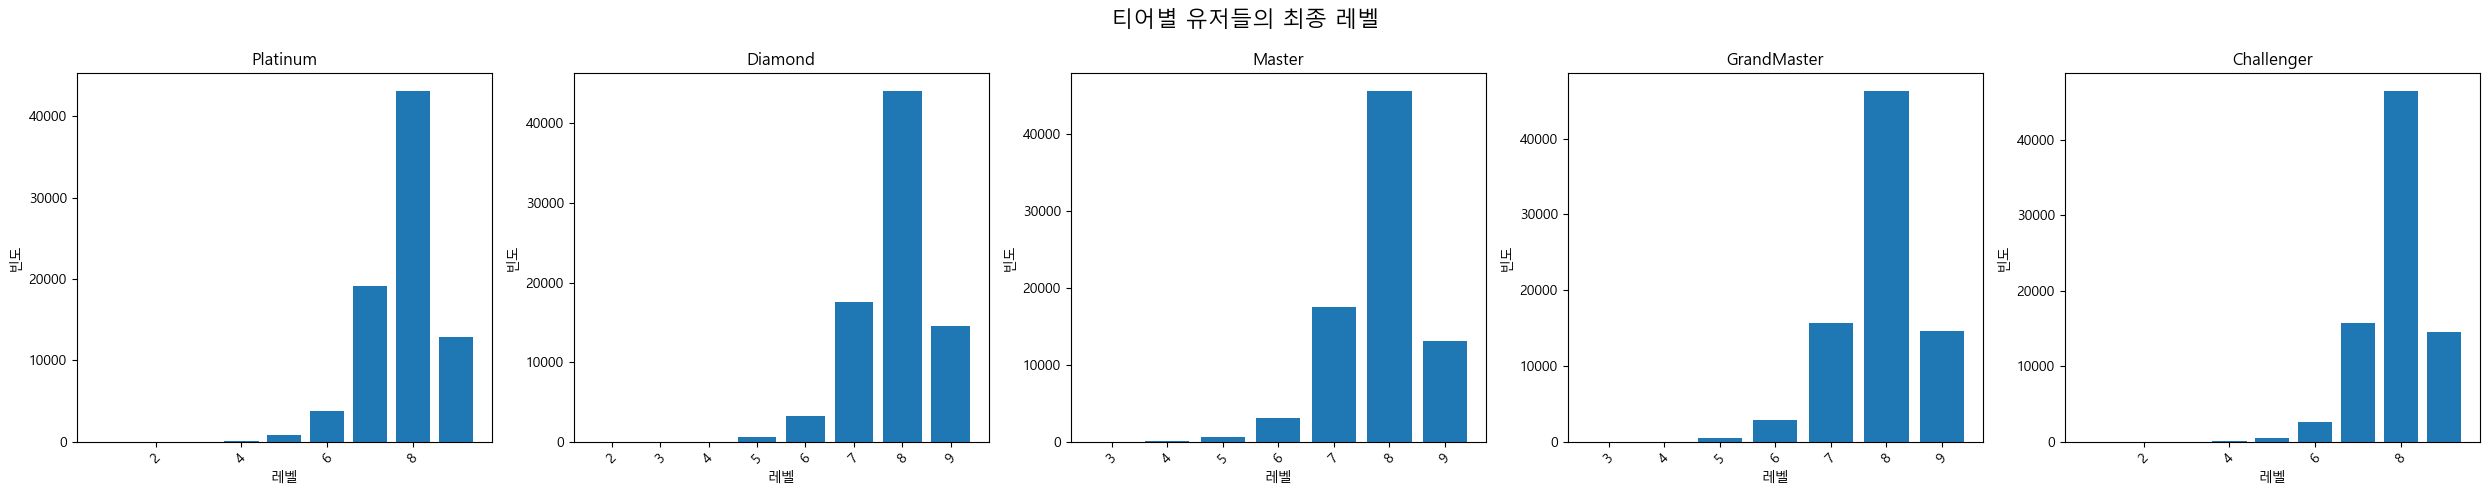

In [75]:
def plot_bar_all(dfs, col, title='', xlabel='', ylabel='빈도'):
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle(title, fontsize=16)

    for ax, (name, df) in zip(axes, dfs.items()):
        counts = df[col].value_counts().sort_index()
        ax.bar(counts.index, counts.values)
        ax.set_title(name)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# 함수 실행
plot_bar_all(dfs, 'level', title='티어별 유저들의 최종 레벨', xlabel='레벨')

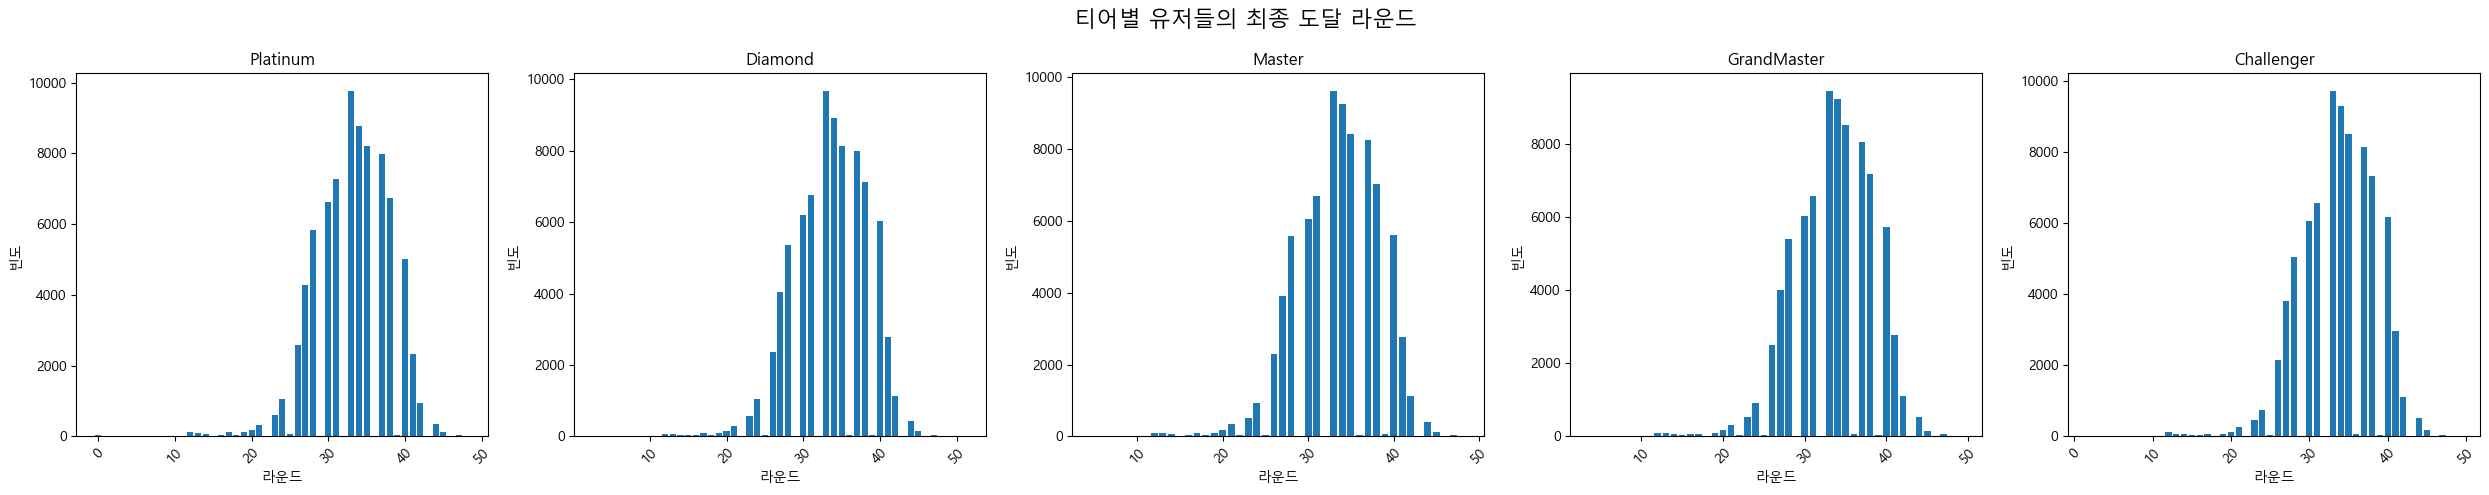

In [76]:
plot_bar_all(dfs,'lastRound', title='티어별 유저들의 최종 도달 라운드', xlabel='라운드')

# 뭔가 이상해서 .unique()확인해봤는데, 그냥 라운드에 번호매긴 느낌이에요..맞는지는 잘 모르겠지만여..

---
#### **유저들의 인게임 체류 시간 분포**
- 이건..그럼 유저 한 명당 게임시간 인건가...????!!!
- 히스토그램 + 박스플롯

In [77]:
print('게임시간 분포 확인 - 인게임 체류시간, 전체 게임시간')
print(df_Challenger_Match['ingameDuration'].describe())
print()
print(df_Challenger_Match['gameDuration'].describe())

게임시간 분포 확인 - 인게임 체류시간, 전체 게임시간
count    79999.000000
mean      1885.009724
std        266.917652
min         38.888447
25%       1714.793335
50%       1905.148804
75%       2070.903687
max       2764.172363
Name: ingameDuration, dtype: float64

count    79999.000000
mean      2159.372816
std        150.723247
min         38.888447
25%       2069.660400
50%       2156.798340
75%       2249.689941
max       2772.365479
Name: gameDuration, dtype: float64


In [78]:
for _, df in dfs.items():
    df['ingameDuration_minute'] = round((df['ingameDuration'] / 60), 2)
    df['gameDuration_minute'] = round((df['gameDuration'] / 60), 2)

In [79]:
for name, df in dfs.items():
    print(f"=== {name} ===")
    print(df[['ingameDuration_minute', 'gameDuration_minute']].describe())
    print()

=== Platinum ===
       ingameDuration_minute  gameDuration_minute
count           80000.000000         80000.000000
mean               31.365369            36.140465
std                 4.653584             2.604945
min                 0.000000             0.000000
25%                28.420000            34.550000
50%                31.720000            36.070000
75%                34.610000            37.700000
max                45.100000            45.240000

=== Diamond ===
       ingameDuration_minute  gameDuration_minute
count           80000.000000         80000.000000
mean               31.231913            35.943499
std                 4.450683             2.286822
min                 2.030000             2.060000
25%                28.320000            34.377500
50%                31.580000            35.880000
75%                34.380000            37.370000
max                45.400000            45.540000

=== Master ===
       ingameDuration_minute  gameDuration_minute


In [80]:
df_Challenger_Match.head(5)

,gameId,gameDuration,level,lastRound,Ranked,ingameDuration,combination,champion,player_cnt,ingameDuration_minute,gameDuration_minute
0,KR_4247538593,2142.470703,8,35,1,2134.272217,"{'DarkStar': 2, 'Protector': 4, 'Rebel': 1, 'S...","{'JarvanIV': {'items': [27], 'star': 3}, 'Sona...",8,35.57,35.71
1,KR_4247538593,2142.470703,9,35,2,2134.272217,"{'Blaster': 2, 'Mercenary': 1, 'Rebel': 6, 'Se...","{'Malphite': {'items': [7], 'star': 2}, 'Yasuo...",8,35.57,35.71
2,KR_4247538593,2142.470703,8,34,3,2073.459229,"{'Cybernetic': 1, 'DarkStar': 3, 'Demolitionis...","{'KaiSa': {'items': [99, 2, 23], 'star': 2}, '...",8,34.56,35.71
3,KR_4247538593,2142.470703,8,33,4,1998.146729,"{'Blaster': 1, 'Cybernetic': 1, 'DarkStar': 1,...","{'KaiSa': {'items': [44, 37], 'star': 2}, 'Ann...",8,33.30,35.71
4,KR_4247538593,2142.470703,9,33,5,1986.443237,"{'Blaster': 2, 'Demolitionist': 2, 'Mercenary'...","{'Ziggs': {'items': [], 'star': 1}, 'Yasuo': {...",8,33.11,35.71


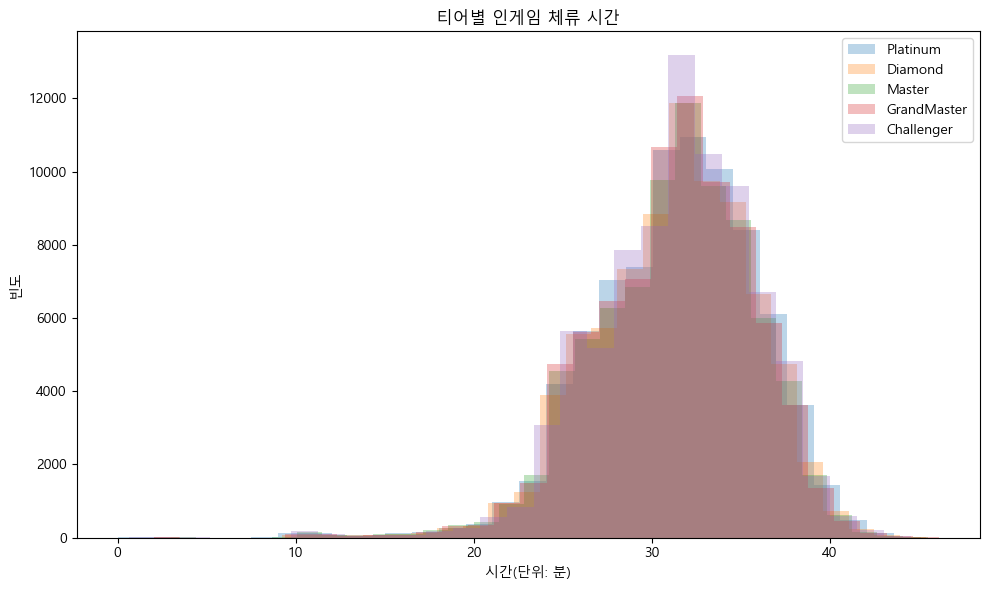

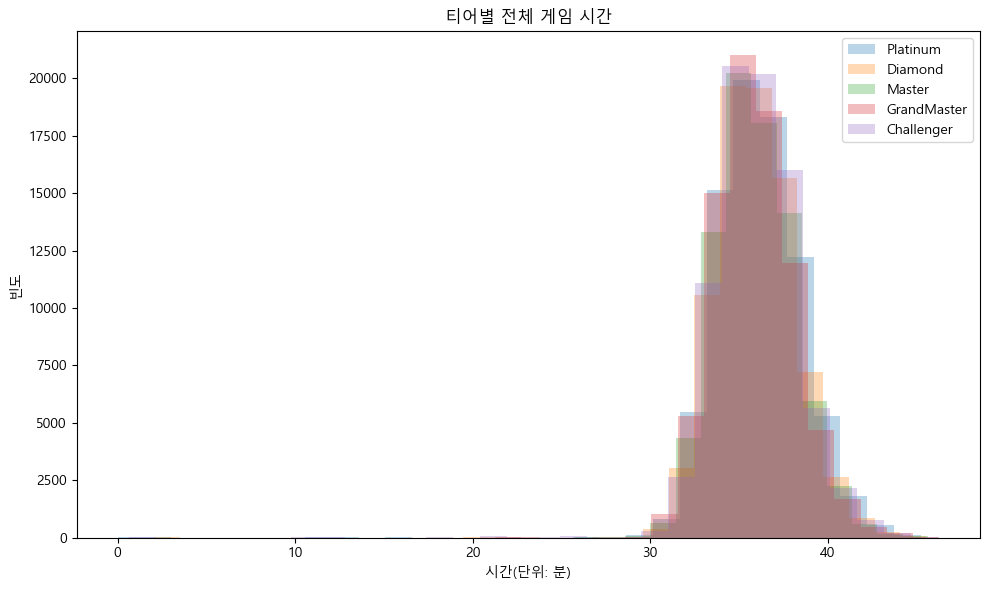

In [81]:
def plot_hist_overlay(dfs, col, title=None, xlabel=None):
    plt.figure(figsize=(10, 6))

    for name, df in dfs.items():
        plt.hist(df[col], bins=30, alpha=0.3, label=name)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('빈도')
    plt.legend()
    plt.tight_layout()
    plt.show()

# 사용법
plot_hist_overlay(dfs, 'ingameDuration_minute', title='티어별 인게임 체류 시간', xlabel='시간(단위: 분)')
plot_hist_overlay(dfs, 'gameDuration_minute', title='티어별 전체 게임 시간', xlabel='시간(단위: 분)')

#### 7. 전체 게임시간 vs 체류시간
- 이게 서로 다르면..게임하다가 게임을 종료한 유저일 가능성이 높다고 하더라구요..?? 맞나여..??
- 산점도 -> 체류시간과 전체 게임 시간이 같았을 때의 선을 기준으로 점이 어디 찍히는지 확인..???

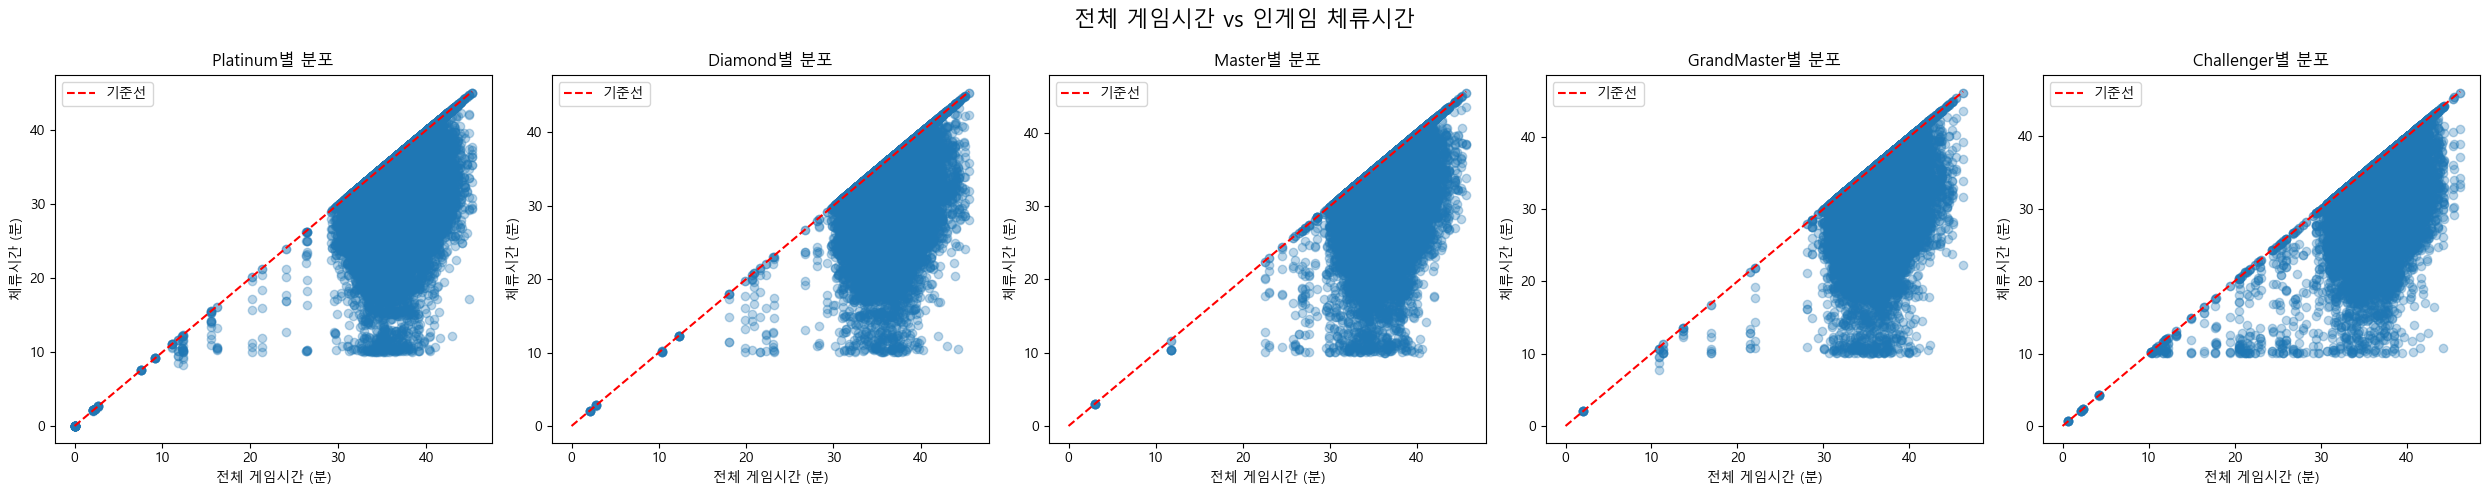

In [83]:
def plot_scatter_all(dfs, x_col, y_col, title=None, xlabel=None, ylabel=None):
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle(title, fontsize=16)

    for i, (name, df) in enumerate(dfs.items()):
        # x=y라는 기준선을 그리기 위해 작성
        # df[x_col].max() - 전체 게임시간의 최댓값
        # df[y_col].max() - 체류시간의 최댓값
        max_val = max(df[x_col].max(), df[y_col].max())
        
        axes[i].scatter(df[x_col], df[y_col], alpha=0.3) # 산점도
        axes[i].plot([0, max_val], [0, max_val], 'r--', label='기준선') # 기준선
        axes[i].set_title(f"{name}별 분포")
        axes[i].set_xlabel(xlabel)
        axes[i].set_ylabel(ylabel)
        axes[i].legend()

    plt.tight_layout()
    plt.show()

# 사용법
plot_scatter_all(dfs, 'gameDuration_minute', 'ingameDuration_minute', 
                title='전체 게임시간 vs 인게임 체류시간', 
                xlabel='전체 게임시간 (분)', 
                ylabel='체류시간 (분)')

In [86]:
for name, df in dfs.items():
    anomaly = df[df['ingameDuration_minute'] > df['gameDuration_minute']]
    zero_game = df[df['gameDuration_minute'] == 0]
    print(f"=== {name} 티어 ===")
    print(f"인게임 체류시간 > 전체 게임시간: {len(anomaly)}개")
    print(f"전체 게임시간 = 0: {len(zero_game)}개")
    print()

=== Platinum 티어 ===
인게임 체류시간 > 전체 게임시간: 0개
전체 게임시간 = 0: 32개

=== Diamond 티어 ===
인게임 체류시간 > 전체 게임시간: 0개
전체 게임시간 = 0: 0개

=== Master 티어 ===
인게임 체류시간 > 전체 게임시간: 0개
전체 게임시간 = 0: 0개

=== GrandMaster 티어 ===
인게임 체류시간 > 전체 게임시간: 0개
전체 게임시간 = 0: 0개

=== Challenger 티어 ===
인게임 체류시간 > 전체 게임시간: 0개
전체 게임시간 = 0: 0개



In [88]:
# 전체 게임 시간이 0인 행만 남긴 뒤, 거기서 게임ID 컬럼만 가져와 -> 고유값을 정리해
zero_games = df_Platinum_Match[df_Platinum_Match['gameDuration_minute'] == 0]['gameId'].unique()

print(f"게임시간 = 0인 고유 게임 수: {len(zero_games)}")
print(f"게임시간이 0인 유저의 수: {len(zero_games) * 8}")

게임시간 = 0인 고유 게임 수: 4
게임시간이 0인 유저의 수: 32


---
롤체
---
- 랭크 포인트는 랭크전에서만 주어짐 -> 그럼 일번모드와 랭크모드를 분리해서 적절한 포인트 설정?

- 만약 특정 레벨의 유저가 많거나, 유저들이 아웃되는 라운드가 비슷하다면? -> 밸런스패치 필요하다고 생각함!

- 확실히 모든 티어에서 게임시간이 길어질수록 유저들의 이탈율이 높음